# CoEvo — как метод улучшает промпт

CoEvo автоматически оптимизирует промпт: раскладывает его на три поля — **роль**, **описание
задачи** и **ограничения на ответ** — и эволюционирует их вместе, используя рефлексию (модель
сама анализирует, чем удачные промпты отличаются от неудачных).

Здесь берём простой промпт для задачи «ответь на вопрос по контексту» и смотрим, насколько
оптимизация поднимает качество (BERTScore).

> Для запуска нужен `OPENAI_API_KEY` и `pip install coolprompt datasets`.

In [1]:
import os
from pathlib import Path
# подхватываем локальный .env, если он есть (иначе достаточно переменной окружения)
for _p in [Path.cwd(), *Path.cwd().parents]:
    _env = _p / ".env"
    if _env.exists():
        for _line in _env.read_text().splitlines():
            if "=" in _line and not _line.lstrip().startswith("#"):
                _k, _v = _line.split("=", 1); os.environ.setdefault(_k.strip(), _v.strip())
        break
assert os.environ.get("OPENAI_API_KEY"), "Нужен OPENAI_API_KEY (или локальный .env)"

import logging, warnings
import matplotlib.pyplot as plt
from datasets import load_dataset
from langchain_openai import ChatOpenAI
from coolprompt.assistant import PromptTuner
from coolprompt.utils.logging_config import logger
for _h in logger.handlers:
    _h.setLevel(logging.ERROR)
logger.propagate = False
warnings.filterwarnings("ignore")
print("готово")

готово


## Данные

Пары «вопрос + контекст → ответ» из открытого QA-набора. Ответы короткие, поэтому промпт,
который этого не учитывает, легко теряет в качестве — есть куда оптимизировать.

In [2]:
ds = load_dataset("rajpurkar/squad_v2", split="validation").filter(
    lambda r: len(r["answers"]["text"]) > 0)
rows = ds.select(list(range(0, 5000, 80))[:60])
dataset = [f"Context: {r['context']}\nQuestion: {r['question']}" for r in rows]
target  = [r["answers"]["text"][0] for r in rows]

print("примеров:", len(dataset))
print("\nвход :", dataset[0][:150], "...")
print("ответ:", target[0])

примеров: 60

вход : Context: The Normans (Norman: Nourmands; French: Normands; Latin: Normanni) were the people who in the 10th and 11th centuries gave their name to Norm ...
ответ: France


## Запуск CoEvo

Стартуем с обычного простого промпта. `PromptTuner.run` сам замерит его качество (baseline),
проведёт оптимизацию и замерит итог. Целевая модель — `gpt-4.1-nano`, оптимизатор — `gpt-4o-mini`.
Попутно собираем лучший результат по эпохам для графика.

In [3]:
START_PROMPT = "Answer the question based on the context."

target_model    = ChatOpenAI(model="gpt-4.1-nano", temperature=0, max_tokens=96, timeout=60, max_retries=3)
optimizer_model = ChatOpenAI(model="gpt-4o-mini", temperature=0.7, max_tokens=1500, timeout=90, max_retries=3)

tuner = PromptTuner(target_model=target_model, system_model=optimizer_model)
tuner.run(
    start_prompt=START_PROMPT,
    task="generation",
    metric="bertscore",
    dataset=dataset,
    target=target,
    method="coevo",
    system_model_as_optimizer=True,
    validation_size=0.34,
    population_size=4,
    num_epochs=5,
    verbose=0,
)
print("оптимизация завершена")

оптимизация завершена


## Результат: было / стало

In [4]:
init_score  = tuner.init_metric
final_score = tuner.final_metric
print(f"стартовый промпт : BERTScore = {init_score:.4f}")
print(f"после CoEvo      : BERTScore = {final_score:.4f}")
print(f"прирост          : {final_score-init_score:+.4f}")

стартовый промпт : BERTScore = 0.8233
после CoEvo      : BERTScore = 0.8963
прирост          : +0.0730


In [5]:
print("Было — один промпт:")
print(" ", tuner.init_prompt, "\n")
print("Стало — три поля, которые подобрал CoEvo:")
print("  роль       :", tuner.final_role)
print("  задача     :", tuner.final_prompt)
print("  ограничения:", tuner.final_constraints)

Было — один промпт:
  Answer the question based on the context. 

Стало — три поля, которые подобрал CoEvo:
  роль       : You are a focused extractor; ensure the answer is directly from the context.
  задача     : Extract the precise answer from the context provided. Respond in JSON format.
  ограничения: Response must be in JSON format, limited to 100 characters, with only the answer as the value.


## Визуализация

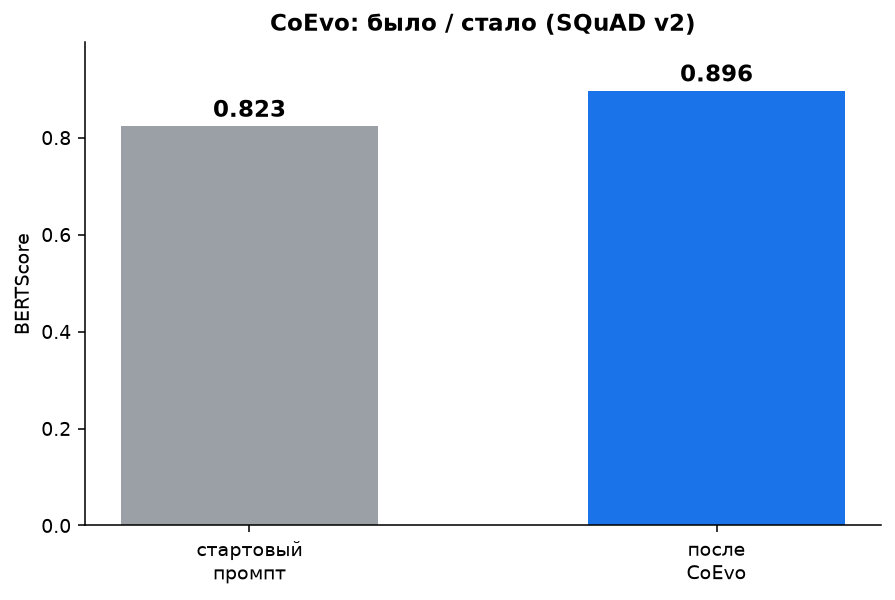

In [6]:
GREY, BLUE = "#9aa0a6", "#1a73e8"
fig, ax = plt.subplots(figsize=(6.5, 4.4))
bars = ax.bar(["стартовый\nпромпт", "после\nCoEvo"], [init_score, final_score],
              color=[GREY, BLUE], width=0.55)
for b, v in zip(bars, [init_score, final_score]):
    ax.text(b.get_x()+b.get_width()/2, v+0.008, f"{v:.3f}", ha="center", va="bottom",
            fontsize=12, fontweight="bold")
ax.set_ylim(0, max(init_score, final_score)+0.1)
ax.set_ylabel("BERTScore")
ax.set_title("CoEvo: было / стало (SQuAD v2)", fontsize=12, fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("coevo_demo_result.png", dpi=140, bbox_inches="tight")
plt.show()

## Вывод

Из одного простого промпта CoEvo собрал структурированный промпт из трёх полей и поднял
BERTScore. Разбиение на роль / задачу / ограничения позволяет улучшать компоненты независимо,
а рефлексия направляет поиск.

Полное сравнение с другими методами на шести датасетах — в `benchmark_coevo.png`.